# EDA + EMBEDDINGS INTEGRITY 

Este notebook comprobamos la integridad de los embeddings, a su vez hacemos EDA.

In [6]:
import pandas as pd
import numpy as np
import ast
import os

# Rutas de archivos
csv_path = r"../data/interim/embeddings/spain_covidMHstrict_occurrences_2020-03_2021-03.csv"
parquet_path = r"../data/interim/embeddings/spain_covidMHstrict_occurrences_2020-03_2021-03.parquet"
clean_output_path = r"../data/interim/embeddings/spain_covidMHstrict_occurrences_2020-03_2021-03_CLEANED.parquet"

# ==============================================================================
# 1. AUDITORÍA DE ESTRUCTURA (Usando el CSV)
# ==============================================================================

# Tu función tal cual me la has pasado
def verify_requirements_wide(df):
    print("\n--- VERIFYING REQUIREMENTS (REAL DATA - WIDE FORMAT) ---")
    
    # --- 1. Identificación y Metadatos ---
    req_cols_ids = ['occurrence_id', 'run_id']
    missing_ids = [c for c in req_cols_ids if c not in df.columns]
    if missing_ids: print(f"❌ MISSING IDs: {missing_ids}")
    else: print("✅ Identification columns present")

    # --- 2. Información Temporal ---
    req_cols_time = ['published_at', 'year', 'month', 'year_month']
    missing_time = [c for c in req_cols_time if c not in df.columns]
    if missing_time: print(f"❌ MISSING Time columns: {missing_time}")
    else: print("✅ Temporal columns present")

    # --- 3. Lingüística y Contexto ---
    req_cols_ling = ['keyword', 'keyword_found', 'context_sentence', 
                     'char_start', 'char_end', 'token_start', 'token_end']
    missing_ling = [c for c in req_cols_ling if c not in df.columns]
    if missing_ling: print(f"❌ MISSING Linguistic columns: {missing_ling}")
    else: print("✅ Linguistic columns present")

    # --- 4. Embeddings ---
    emb_cols = [
        'embedding_baseline_last4_concat', 
        'embedding_baseline_penultimate',
        'embedding_dapt_last4_concat', 
        'embedding_dapt_penultimate'
    ]
    missing_emb = [c for c in emb_cols if c not in df.columns]
    
    if missing_emb:
        print(f"❌ MISSING Embedding columns: {missing_emb}")
    else:
        print("✅ All 4 Embedding columns present")

# Ejecución Parte 1
if os.path.exists(csv_path):
    print(f"📂 Cargando CSV para check de estructura: {csv_path}")
    df_csv = pd.read_csv(csv_path)
    verify_requirements_wide(df_csv)
    del df_csv # Liberamos memoria
else:
    print(f"⚠️ No encuentro el CSV en: {csv_path}")


# ==============================================================================
# 2. AUDITORÍA DE INTEGRIDAD Y REPARACIÓN (Usando el Parquet)
# ==============================================================================
print("\n" + "="*50)
print("INICIANDO CHECK DE INTEGRIDAD Y FORMATO (PARQUET)")
print("="*50)

if os.path.exists(parquet_path):
    print(f"📂 Cargando Parquet: {parquet_path}")
    df_parquet = pd.read_parquet(parquet_path)
    
    emb_cols = [
        'embedding_baseline_last4_concat', 
        'embedding_baseline_penultimate',
        'embedding_dapt_last4_concat', 
        'embedding_dapt_penultimate'
    ]
    
    changes_made = False # Bandera para saber si guardamos al final

    print("\n--- REVISANDO FORMATO DE EMBEDDINGS ---")

    for col in emb_cols:
        if col not in df_parquet.columns:
            print(f"⚠️ Columna no encontrada: {col}")
            continue
            
        # Tomamos una muestra para ver si es string o array
        sample = df_parquet[col].dropna().iloc[0]
        
        # --- A. CORRECCIÓN DE FORMATO (String -> Array) ---
        if isinstance(sample, str):
            print(f"🔄 La columna '{col}' es TEXTO (String). Convirtiendo a ARRAYS reales...")
            try:
                # La conversión mágica
                df_parquet[col] = df_parquet[col].apply(lambda x: np.array(ast.literal_eval(x)) if isinstance(x, str) else x)
                print(f"   ✅ Conversión completada.")
                changes_made = True # ¡Importante! Hemos modificado el dataframe
            except Exception as e:
                print(f"   ❌ Error convirtiendo '{col}': {e}")
        
        # --- B. CHEQUEO DE INTEGRIDAD (SVD CHECK) ---
        print(f"🔍 Buscando NaNs/Infs en '{col}'...")
        
        try:
            # Stackeamos para crear una matriz 2D numpy y chequear todo de golpe
            # Usamos dropna() porque filas vacías se manejan aparte
            matrix_check = np.vstack(df_parquet[col].dropna().values)
            
            nans_in_matrix = np.isnan(matrix_check).sum()
            infs_in_matrix = np.isinf(matrix_check).sum()
            null_rows = df_parquet[col].isnull().sum()
            
            if nans_in_matrix > 0 or infs_in_matrix > 0:
                print(f"   🚨 ALERTA ROJA: Problemas numéricos en '{col}':")
                print(f"      - Valores NaN internos: {nans_in_matrix}")
                print(f"      - Valores Infinitos: {infs_in_matrix}")
                
                # Opcional: Si quieres arreglarlos automáticamente descomenta esto:
                # print("   🔧 Intentando reparar (Rellenando con 0)...")
                # df_parquet[col] = df_parquet[col].apply(lambda x: np.nan_to_num(x) if isinstance(x, (list, np.ndarray)) else x)
                # changes_made = True
                
            elif null_rows > 0:
                print(f"   ⚠️ Advertencia: {null_rows} filas vacías (nulls).")
            else:
                print(f"   ✅ Columna limpia. Lista para SVD. (Dimensión base: {matrix_check.shape})")
                
        except Exception as e:
            print(f"   ⚠️ No se pudo verificar matriz completa (¿posiblemente longitudes desiguales?): {e}")

    # --- C. GUARDADO CONDICIONAL ---
    if changes_made:
        print("\n💾 SE HAN DETECTADO CAMBIOS EN EL FORMATO.")
        print(f"   Guardando versión limpia en: {clean_output_path}")
        df_parquet.to_parquet(clean_output_path)
        print("   ✅ Guardado exitoso. Usa ESTE archivo para la Fase 3.")
    else:
        print("\n👌 No se requirieron cambios de formato. El parquet original está bien.")

else:
    print(f"❌ No encuentro el archivo Parquet en: {parquet_path}")

📂 Cargando CSV para check de estructura: ../data/interim/embeddings/spain_covidMHstrict_occurrences_2020-03_2021-03.csv

--- VERIFYING REQUIREMENTS (REAL DATA - WIDE FORMAT) ---
✅ Identification columns present
✅ Temporal columns present
✅ Linguistic columns present
✅ All 4 Embedding columns present

INICIANDO CHECK DE INTEGRIDAD Y FORMATO (PARQUET)
📂 Cargando Parquet: ../data/interim/embeddings/spain_covidMHstrict_occurrences_2020-03_2021-03.parquet

--- REVISANDO FORMATO DE EMBEDDINGS ---
🔄 La columna 'embedding_baseline_last4_concat' es TEXTO (String). Convirtiendo a ARRAYS reales...
   ✅ Conversión completada.
🔍 Buscando NaNs/Infs en 'embedding_baseline_last4_concat'...
   ✅ Columna limpia. Lista para SVD. (Dimensión base: (7535, 3072))
🔄 La columna 'embedding_baseline_penultimate' es TEXTO (String). Convirtiendo a ARRAYS reales...
   ✅ Conversión completada.
🔍 Buscando NaNs/Infs en 'embedding_baseline_penultimate'...
   ✅ Columna limpia. Lista para SVD. (Dimensión base: (7535, 768

---

In [7]:
def check_date_ranges(df):
    if 'published_at' in df.columns:
        print(f"\nDate Range: {df['published_at'].min()} to {df['published_at'].max()}")

In [ ]:

df_csv 

check_date_ranges(df_csv)


Date Range: 2020-03-04 23:15:00+00:00 to 2021-03-31 07:45:00+00:00


Advanced EDA

In [9]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set up visual style
plt.style.use('seaborn-v0_8')
sns.set_context("talk")

In [10]:
def advanced_eda(df):
    print("\n--- ADVANCED EDA PLOTS ---")
    
    # Temporal Distribution
    if 'year_month' in df.columns:
        plt.figure(figsize=(12, 6))
        df['year_month'].sort_values().value_counts(sort=False).plot(kind='bar')
        plt.title("Distribution of Occurrences by Year-Month")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
    # Model x Layer Strategy
    if 'model_variant' in df.columns and 'layer_strategy' in df.columns:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, x='model_variant', hue='layer_strategy')
        plt.title("Count of Occurrences by Model Variant and Layer Strategy")
        plt.show()


--- ADVANCED EDA PLOTS ---


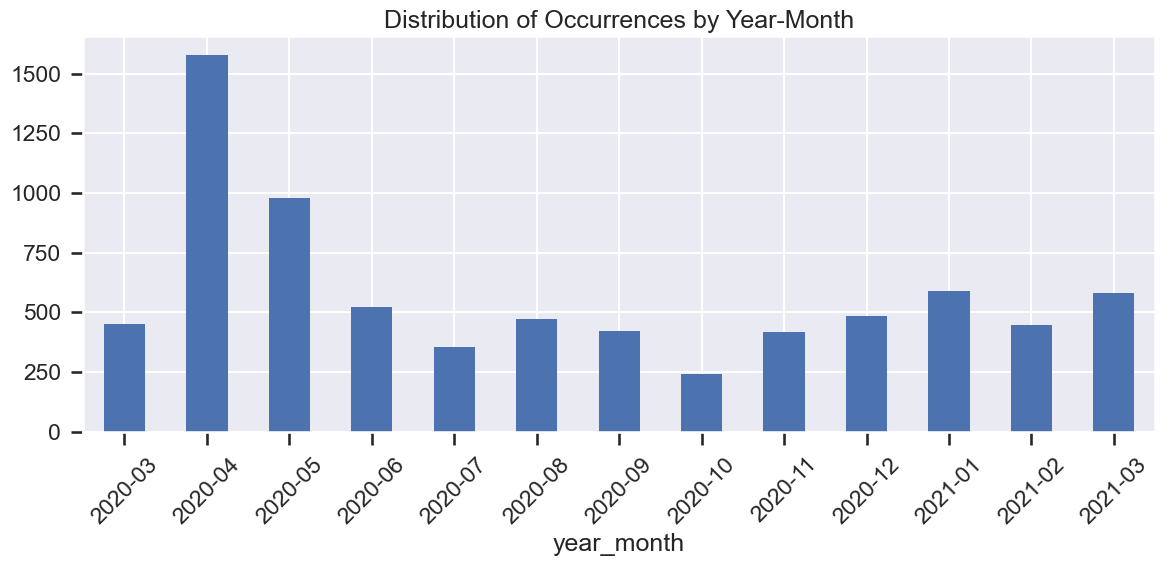

In [13]:
advanced_eda(df_parquet)